In [6]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [220]:
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

## Pregunta Inicial
- **Hipótesis en Bruto**:
	- Quien tiene mayor porcentaje de victorias Strikers o Grapplers?
	- Quien tiene peleas mas largas Strikers o Grapplers?
	- Cual es el porcentaje de victorias por tipo de peleador? (Strikers Vs Grapplers)
	- Que marca la diferencia en los encuentros?
	- Con que atributos esta relacionada la apuesta del peleador?
- **Hipótesis Finales (Base)**:
	- Existe una relación ente las apuestas (Favorito Vs UnderDog) con la victoria?
	- De qué manera esta relacionado el arquetipo del peleador con el resultado de la pelea? (Tiempo, Manera de Finalización)
	- Existe un patrón que explique el fenómeno de "La Invasión Daguestani"?

### Descargando Dataset 

In [7]:
path = kagglehub.dataset_download("mdabbert/ultimate-ufc-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/scoria/.cache/kagglehub/datasets/mdabbert/ultimate-ufc-dataset/versions/181


## Funciones

In [218]:
def generar_perfil_completo(nombre, df_ufc):
    mask = (df_ufc['R_fighter'] == nombre) | (df_ufc['B_fighter'] == nombre)
    participaciones = df_ufc[mask].copy()
    
    if participaciones.empty:
        return pd.Series([[], 0, 0, 0, 0, 0, 0, 0])

    indices_peleas = participaciones.index.tolist()
    total_fights = len(participaciones)
    
    wins, losses, draws = 0, 0, 0
    resultados_historicos = []

    for _, row in participaciones.iterrows():
        winner = row['Winner']
        if winner == 'Draw':
            res = 'D'; draws += 1
        elif (winner == 'Red' and row['R_fighter'] == nombre) or \
             (winner == 'Blue' and row['B_fighter'] == nombre):
            res = 'W'; wins += 1
        else:
            res = 'L'; losses += 1
        resultados_historicos.append(res)
    
    historial_rev = resultados_historicos[::-1]
    racha_w, racha_l, racha_d = 0, 0, 0
    
    if historial_rev:
        ultimo_res = historial_rev[0]
        for res in historial_rev:
            if res == ultimo_res:
                if res == 'W': racha_w += 1
                elif res == 'L': racha_l += 1
                elif res == 'D': racha_d += 1
            else:
                break
                
    return pd.Series([
        indices_peleas, total_fights, wins, losses, draws, 
        racha_w, racha_l, racha_d
    ])

In [255]:
def clasificar_arquetipo_base(row):
    td = row['avg_TD_landed']
    sub = row['avg_SUB_ATT']
    sig = row['avg_SIG_STR_landed']

    # Perfeccionar clasificacion
    es_grappler = (td > 1.5) or (sub > 0.7)
    es_striker  = (sig > 15) and (td < 1.0)
    
    if es_grappler and not es_striker:
        return 'Grappler'
    elif es_striker and not es_grappler:
        return 'Striker'
    else:
        return 'Completo'

### Importando Bibliotecas

In [10]:
import pandas as pd

### Cargando el DataFrame

In [11]:
df_ufc = pd.read_csv(f"{path}/ufc-master.csv")

*Primera Vista*

In [99]:
df_ufc.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,...,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Punches,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,Knee,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0


## 1. Sanity Check

In [13]:
print(df_ufc.shape)

(7177, 118)


In [14]:
df_ufc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7177 entries, 0 to 7176
Columns: 118 entries, R_fighter to b_ko_odds
dtypes: bool(1), float64(60), int64(43), object(14)
memory usage: 6.4+ MB


In [15]:
df_ufc.columns

Index(['R_fighter', 'B_fighter', 'R_odds', 'B_odds', 'R_ev', 'B_ev', 'date',
       'location', 'country', 'Winner',
       ...
       'finish_details', 'finish_round', 'finish_round_time',
       'total_fight_time_secs', 'r_dec_odds', 'b_dec_odds', 'r_sub_odds',
       'b_sub_odds', 'r_ko_odds', 'b_ko_odds'],
      dtype='object', length=118)

In [16]:
df_ufc['R_fighter'].unique()

array(['Israel Adesanya', 'Alexa Grasso', 'Michael Chiesa', ...,
       'Caol Uno', 'Eliot Marshall', 'Eric Schafer'],
      shape=(1771,), dtype=object)

In [17]:
df_ufc['B_fighter'].unique()

array(['Joe Pyfer', 'Maycee Barber', 'Niko Price', ..., 'James Irvin',
       'Shannon Gugerty', 'Chase Gormley'], shape=(2054,), dtype=object)

In [98]:
df_ufc.describe()

,R_odds,B_odds,R_ev,B_ev,date,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,...,B_Flyweight_rank,B_Pound-for-Pound_rank,finish_round,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
count,6937.000000,6938.000000,6937.000000,6938.000000,7177,7177.000000,7177.000000,7177.000000,7177.000000,6247.000000,...,143.000000,81.000000,6555.000000,6555.000000,6062.000000,6032.000000,5813.000000,5789.000000,5815.000000,5788.000000
mean,-114.380280,56.003459,98.775801,165.136205,2018-11-18 18:07:40.470948864,3.187126,0.502996,1.002229,0.025916,18.211118,...,8.440559,9.370370,2.423036,657.684821,315.757176,431.808687,995.132118,1211.647608,596.026827,729.980477
min,-2100.000000,-2200.000000,4.761900,4.545500,2010-03-21 00:00:00,3.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,5.000000,-440.000000,-200.000000,-370.000000,-1250.000000,-900.000000,-400.000000
25%,-255.000000,-150.000000,39.215700,66.666700,2015-03-14 00:00:00,3.000000,0.000000,0.000000,0.000000,3.745000,...,5.000000,5.000000,1.000000,299.000000,170.000000,220.000000,450.000000,600.000000,240.000000,320.000000
50%,-148.000000,130.000000,67.567600,130.000000,2019-02-02 00:00:00,3.000000,0.000000,0.000000,0.000000,6.120000,...,8.000000,10.000000,3.000000,900.000000,260.000000,350.000000,800.000000,1000.000000,450.000000,550.000000
75%,130.000000,215.000000,130.000000,215.000000,2022-09-10 00:00:00,3.000000,1.000000,1.000000,0.000000,30.433050,...,12.000000,14.000000,3.000000,900.000000,420.000000,550.000000,1300.000000,1550.000000,762.500000,900.000000
max,1100.000000,1300.000000,1100.000000,1300.000000,2026-03-28 00:00:00,5.000000,6.000000,15.000000,2.000000,154.000000,...,15.000000,15.000000,5.000000,1500.000000,2400.000000,3500.000000,10000.000000,12500.000000,5000.000000,6600.000000
std,285.370533,260.799641,90.112714,140.153769,NaN,0.579962,0.797343,1.465126,0.164074,19.825099,...,4.284960,4.357305,1.009258,360.670777,260.648779,337.468752,816.926221,903.365182,638.926484,699.021015


In [97]:
df_ufc['R_fighter'] = df_ufc['R_fighter'].str.strip()
df_ufc['B_fighter'] = df_ufc['B_fighter'].str.strip()

In [82]:
df_ufc['date'].describe()

count           7177
unique           616
top       2016-11-19
freq              24
Name: date, dtype: object

In [83]:
df_ufc['date'] = pd.to_datetime(df_ufc['date'])

In [84]:
print(df_ufc['date'].dtype)

datetime64[ns]


In [128]:
df_ufc = df_ufc.sort_values(by='date', ascending=True).reset_index(drop=True)

## Cual es el periodo de tiempo en el que se encuentran nuestros datos?

In [129]:
df_ufc['date'].head()

0   2010-03-21
1   2010-03-21
2   2010-03-21
3   2010-03-21
4   2010-03-21
Name: date, dtype: datetime64[ns]

In [130]:
df_ufc['date'].tail()

7172   2026-03-28
7173   2026-03-28
7174   2026-03-28
7175   2026-03-28
7176   2026-03-28
Name: date, dtype: datetime64[ns]

Van desde **(2010-03-21 hasta 2026-03-28)**

## Atributos de Acciones

In [21]:
df_ufc[['B_avg_SIG_STR_landed', 'R_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct', 'R_avg_SIG_STR_pct', 'B_avg_SUB_ATT', 'R_avg_SUB_ATT', 'B_avg_TD_landed', 'R_avg_TD_landed', 'B_avg_TD_pct', 'R_avg_TD_pct']].describe()

,B_avg_SIG_STR_landed,R_avg_SIG_STR_landed,B_avg_SIG_STR_pct,R_avg_SIG_STR_pct,B_avg_SUB_ATT,R_avg_SUB_ATT,B_avg_TD_landed,R_avg_TD_landed,B_avg_TD_pct,R_avg_TD_pct
count,6247.000000,6722.000000,6412.000000,6820.000000,6345.000000,6820.000000,6344.000000,6820.000000,6335.000000,6810.000000
mean,18.211118,19.529597,0.456023,0.462621,0.499645,0.535286,1.347529,1.428983,0.326992,0.344957
std,19.825099,19.547405,0.108546,0.096235,0.678532,0.703734,1.377428,1.344243,0.236926,0.219053
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.745000,3.990000,0.400000,0.410000,0.000000,0.000000,0.333300,0.461500,0.160000,0.206000
50%,6.120000,8.170000,0.460000,0.460000,0.300000,0.333300,1.000000,1.070000,0.330000,0.340000
75%,30.433050,32.000000,0.520000,0.520000,0.800000,0.800000,2.000000,2.000000,0.470000,0.472000
max,154.000000,141.000000,1.000000,1.000000,8.400000,14.300000,10.860000,14.290000,1.000000,1.000000


### Separar en DF's para recuperar todas las estadisticas del peleador (Acciones y Caracteristicas)

In [160]:
cols_interes = [
    'fighter', 'avg_SIG_STR_landed', 'avg_SIG_STR_pct', 
    'avg_SUB_ATT', 'avg_TD_landed', 'avg_TD_pct', 
    'Height_cms', 'Reach_cms', 'Weight_lbs', 'age', 'Stance'
]

### DF's (Red y Blue)

In [162]:
df_red = df_ufc[['R_' + col for col in cols_interes]].copy()
df_red.columns = cols_interes

In [24]:
df_blue = df_ufc[['B_' + col for col in cols_interes]].copy()
df_blue.columns = cols_interes

### DF Red

In [25]:
df_red.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Israel Adesanya,4.03,0.48,0.1,0.05,0.09,193.04,203.20,185,36,Switch
1,Alexa Grasso,4.11,0.41,0.7,0.40,0.35,165.10,167.64,125,32,Orthodox
2,Michael Chiesa,2.02,0.40,1.0,3.11,0.47,185.42,190.50,170,38,Southpaw
3,Julian Erosa,6.18,0.48,0.7,1.73,0.43,185.42,187.96,145,36,Southpaw
4,Mansur Abdul-Malik,3.28,0.44,0.3,1.65,0.41,187.96,203.20,185,28,Orthodox


In [26]:
df_red.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
7172,Duane Ludwig,13.6667,0.577,0.0000,0.0000,0.000,177.80,177.80,170,31,Orthodox
7173,John Howard,18.0000,0.550,1.0000,4.6667,0.790,170.18,180.34,170,27,Orthodox
7174,Brendan Schaub,12.0000,0.250,0.0000,0.0000,0.000,193.04,198.12,245,27,Orthodox
7175,Mike Pierce,40.5000,0.405,0.0000,3.5000,0.520,172.72,177.80,170,29,Orthodox
7176,Eric Schafer,15.6667,0.588,1.3333,0.8333,0.145,190.50,190.50,185,32,Orthodox


In [27]:
df_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7177 entries, 0 to 7176
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fighter             7177 non-null   object 
 1   avg_SIG_STR_landed  6722 non-null   float64
 2   avg_SIG_STR_pct     6820 non-null   float64
 3   avg_SUB_ATT         6820 non-null   float64
 4   avg_TD_landed       6820 non-null   float64
 5   avg_TD_pct          6810 non-null   float64
 6   Height_cms          7177 non-null   float64
 7   Reach_cms           7177 non-null   float64
 8   Weight_lbs          7177 non-null   int64  
 9   age                 7177 non-null   int64  
 10  Stance              7177 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 616.9+ KB


### DF Blue

In [28]:
df_blue.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Joe Pyfer,3.52,0.44,0.9,1.45,0.30,187.96,190.50,185,29,Orthodox
1,Maycee Barber,4.56,0.53,0.1,1.56,0.45,165.10,165.10,125,27,Switch
2,Niko Price,5.11,0.43,0.6,1.06,0.30,182.88,193.04,170,36,Orthodox
3,Lerryan Douglas,8.67,0.64,0.0,0.00,0.00,175.26,182.88,145,30,Orthodox
4,Yousri Belgaroui,6.10,0.64,0.0,0.29,1.00,198.12,200.66,185,33,Orthodox


In [29]:
df_blue.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
7172,Darren Elkins,NaN,NaN,NaN,NaN,NaN,177.80,180.34,145,25,Orthodox
7173,Daniel Roberts,NaN,NaN,NaN,NaN,NaN,177.80,187.96,170,29,Southpaw
7174,Chase Gormley,8.0000,0.34,1.0000,1.0000,1.0,190.50,196.00,265,27,Orthodox
7175,Julio Paulino,NaN,NaN,NaN,NaN,NaN,182.88,185.42,170,34,Orthodox
7176,Jason Brilz,31.6667,0.46,0.6667,1.6667,0.5,180.34,180.34,205,34,Orthodox


In [30]:
df_blue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7177 entries, 0 to 7176
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fighter             7177 non-null   object 
 1   avg_SIG_STR_landed  6247 non-null   float64
 2   avg_SIG_STR_pct     6412 non-null   float64
 3   avg_SUB_ATT         6345 non-null   float64
 4   avg_TD_landed       6344 non-null   float64
 5   avg_TD_pct          6335 non-null   float64
 6   Height_cms          7177 non-null   float64
 7   Reach_cms           7177 non-null   float64
 8   Weight_lbs          7177 non-null   int64  
 9   age                 7177 non-null   int64  
 10  Stance              7171 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 616.9+ KB


### Unimos los DF's en uno solo

In [31]:
df_red_blue = pd.concat([df_red, df_blue], axis=0, ignore_index=True)

In [32]:
df_red_blue.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Israel Adesanya,4.03,0.48,0.1,0.05,0.09,193.04,203.20,185,36,Switch
1,Alexa Grasso,4.11,0.41,0.7,0.40,0.35,165.10,167.64,125,32,Orthodox
2,Michael Chiesa,2.02,0.40,1.0,3.11,0.47,185.42,190.50,170,38,Southpaw
3,Julian Erosa,6.18,0.48,0.7,1.73,0.43,185.42,187.96,145,36,Southpaw
4,Mansur Abdul-Malik,3.28,0.44,0.3,1.65,0.41,187.96,203.20,185,28,Orthodox


In [33]:
df_red_blue.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
14349,Darren Elkins,NaN,NaN,NaN,NaN,NaN,177.80,180.34,145,25,Orthodox
14350,Daniel Roberts,NaN,NaN,NaN,NaN,NaN,177.80,187.96,170,29,Southpaw
14351,Chase Gormley,8.0000,0.34,1.0000,1.0000,1.0,190.50,196.00,265,27,Orthodox
14352,Julio Paulino,NaN,NaN,NaN,NaN,NaN,182.88,185.42,170,34,Orthodox
14353,Jason Brilz,31.6667,0.46,0.6667,1.6667,0.5,180.34,180.34,205,34,Orthodox


In [34]:
df_red_blue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14354 entries, 0 to 14353
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fighter             14354 non-null  object 
 1   avg_SIG_STR_landed  12969 non-null  float64
 2   avg_SIG_STR_pct     13232 non-null  float64
 3   avg_SUB_ATT         13165 non-null  float64
 4   avg_TD_landed       13164 non-null  float64
 5   avg_TD_pct          13145 non-null  float64
 6   Height_cms          14354 non-null  float64
 7   Reach_cms           14354 non-null  float64
 8   Weight_lbs          14354 non-null  int64  
 9   age                 14354 non-null  int64  
 10  Stance              14348 non-null  object 
dtypes: float64(7), int64(2), object(2)
memory usage: 1.2+ MB


In [35]:
df_red_blue['fighter'].unique()

array(['Israel Adesanya', 'Alexa Grasso', 'Michael Chiesa', ...,
       'Paul Buentello', 'Shannon Gugerty', 'Chase Gormley'],
      shape=(2241,), dtype=object)

In [36]:
df_red_blue.dropna()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Israel Adesanya,4.0300,0.480,0.1000,0.0500,0.090,193.04,203.20,185,36,Switch
1,Alexa Grasso,4.1100,0.410,0.7000,0.4000,0.350,165.10,167.64,125,32,Orthodox
2,Michael Chiesa,2.0200,0.400,1.0000,3.1100,0.470,185.42,190.50,170,38,Southpaw
3,Julian Erosa,6.1800,0.480,0.7000,1.7300,0.430,185.42,187.96,145,36,Southpaw
4,Mansur Abdul-Malik,3.2800,0.440,0.3000,1.6500,0.410,187.96,203.20,185,28,Orthodox
...,...,...,...,...,...,...,...,...,...,...,...
14346,James Irvin,5.2500,0.555,0.1250,0.0000,0.000,187.96,190.50,205,31,Orthodox
14347,Shannon Gugerty,10.7500,0.333,1.2500,1.2500,0.663,177.80,180.34,155,28,Orthodox
14348,Vladimir Matyushenko,22.1667,0.510,0.1667,2.5000,0.480,182.88,187.96,205,39,Orthodox
14351,Chase Gormley,8.0000,0.340,1.0000,1.0000,1.000,190.50,196.00,265,27,Orthodox


In [156]:
df_red_blue.loc[df_red_blue['fighter'] == 'Ilia Topuria']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,Height_cms,Reach_cms,Weight_lbs,age,Stance
372,Ilia Topuria,4.81,0.48,1.1,1.96,0.61,170.18,175.26,155,28,Orthodox
712,Ilia Topuria,4.69,0.47,1.1,2.02,0.61,170.18,175.26,145,27,Orthodox
2680,Ilia Topuria,0.87,0.39,5.0,5.00,0.55,170.18,175.26,145,23,Orthodox
8266,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,27,Orthodox
8582,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,26,Orthodox
8846,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,25,Orthodox
9231,Ilia Topuria,4.40,0.46,1.3,1.92,0.56,170.18,175.26,145,25,Orthodox
9578,Ilia Topuria,2.77,0.48,3.4,3.35,0.55,170.18,175.26,145,24,Orthodox
9938,Ilia Topuria,0.00,0.00,0.0,0.00,0.00,170.18,170.18,145,23,Orthodox


### Separamos el DF unificado (Red y Blue) en DF's especificos (Acciones y Caractersiticas)

In [37]:
df_peleador_acciones = df_red_blue.groupby('fighter').agg({
    'avg_SIG_STR_landed': 'mean',
    'avg_SIG_STR_pct': 'mean',
    'avg_SUB_ATT': 'mean',
    'avg_TD_landed': 'mean',
    'avg_TD_pct': 'mean'
}).reset_index()

In [38]:
df_peleador_caracteristicas = df_red_blue.groupby('fighter').agg({
    'Height_cms': 'last',
    'Reach_cms': 'last',
    'Weight_lbs': 'last',
    'age': 'max',
    'Stance': 'last'
}).reset_index()

In [201]:
df_peleador_acciones['arquetipo_base'] = df_peleador_acciones.apply(
    clasificar_arquetipo_base, axis=1
)

In [39]:
peleas_red = df_ufc.groupby('R_fighter').apply(lambda x: x.index.tolist()).to_dict()
peleas_blue = df_ufc.groupby('B_fighter').apply(lambda x: x.index.tolist()).to_dict()

/tmp/ipykernel_2714/2803255360.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peleas_red = df_ufc.groupby('R_fighter').apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_2714/2803255360.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peleas_blue = df_ufc.groupby('B_fighter').apply(lambda x: x.index.tolist()).to_dict()


In [124]:
df_peleador_record = df_red_blue[['fighter']].drop_duplicates().reset_index(drop=True)

In [125]:
columnas_nuevas = [
    'indices_peleas', 'total_fights', 'wins', 'losses', 'draws', 
    'current_win_streak', 'current_loss_streak', 'current_draw_streak'
]

In [143]:
df_peleador_record[columnas_nuevas] = df_peleador_record['fighter'].apply(
    lambda x: generar_perfil_completo(x, df_ufc)
)

### DF Acciones 

In [202]:
df_peleador_acciones = df_peleador_acciones.dropna(subset=['fighter'])

In [203]:
df_peleador_acciones.shape

(2241, 7)

In [204]:
df_peleador_acciones.head()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
0,Jun Yong Park,NaN,0.522,0.00,0.50,0.25,All-Around
1,AJ Cunningham,5.94,0.290,0.25,0.00,0.00,All-Around
2,AJ Dobson,4.29,0.460,0.30,1.67,0.75,Grappler
3,AJ Fletcher,3.36,0.490,0.90,1.54,0.35,Grappler
4,Aalon Cruz,8.31,0.395,0.00,0.00,0.00,All-Around


In [205]:
df_peleador_acciones.tail()

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
2236,Zhang Weili,5.577778,0.514444,0.544444,2.162222,0.412222,Grappler
2237,Zu Anyanwu,NaN,NaN,NaN,NaN,NaN,All-Around
2238,Zubaira Tukhugov,16.528571,0.392143,0.000000,2.286186,0.450000,Grappler
2239,Zviad Lazishvili,4.200000,0.390000,0.000000,0.000000,0.000000,All-Around
2240,Zygimantas Ramaska,0.960000,0.600000,2.400000,0.000000,0.000000,Grappler


In [206]:
df_peleador_acciones.describe()

,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct
count,2135.000000,2149.000000,2144.000000,2144.000000,2144.000000
mean,16.952937,0.447141,0.485682,1.317959,0.310135
std,16.403671,0.112304,0.766311,1.423511,0.236860
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.049545,0.387667,0.000000,0.257215,0.125000
50%,10.136108,0.452500,0.228571,0.925248,0.301321
75%,26.831650,0.514444,0.712620,1.966615,0.458500
max,121.000000,0.860000,14.300000,14.290000,1.000000


### Peleadores especificos

In [207]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Ilia Topuria']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
845,Ilia Topuria,3.415556,0.406667,1.755556,2.223333,0.506667,Grappler


In [208]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Diego Lopes']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
587,Diego Lopes,3.65,0.518889,2.733333,0.551111,0.366667,Grappler


In [210]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Georges St-Pierre']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
758,Georges St-Pierre,53.763657,0.570857,1.1873,3.889357,0.746714,Grappler


In [211]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Jon Jones']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
1061,Jon Jones,35.343458,0.561263,0.516753,2.063526,0.589316,Grappler


In [212]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Conor McGregor']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
455,Conor McGregor,29.551292,0.476923,0.007692,0.870377,0.366308,Striker


In [214]:
df_peleador_acciones.loc[df_peleador_acciones['fighter'] == 'Zabit Magomedsharipov']

,fighter,avg_SIG_STR_landed,avg_SIG_STR_pct,avg_SUB_ATT,avg_TD_landed,avg_TD_pct,arquetipo_base
2221,Zabit Magomedsharipov,49.166675,0.5744,1.26,4.72734,0.5026,Grappler


### DF Caracteristicas

In [60]:
df_peleador_caracteristicas = df_peleador_caracteristicas.dropna(subset=['fighter'])

In [61]:
df_peleador_caracteristicas.shape

(2241, 6)

In [62]:
df_peleador_caracteristicas.head()

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
0,Jun Yong Park,177.80,185.42,185,28,Orthodox
1,AJ Cunningham,177.80,180.34,145,30,Orthodox
2,AJ Dobson,185.42,193.04,185,32,Orthodox
3,AJ Fletcher,177.80,170.18,170,26,Switch
4,Aalon Cruz,182.88,198.12,145,31,Switch


In [63]:
df_peleador_caracteristicas.tail()

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
2236,Zhang Weili,162.56,160.02,115,36,Switch
2237,Zu Anyanwu,185.42,195.58,251,36,Orthodox
2238,Zubaira Tukhugov,172.72,172.72,145,32,Orthodox
2239,Zviad Lazishvili,167.64,175.26,135,29,Orthodox
2240,Zygimantas Ramaska,180.34,180.34,145,27,Orthodox


In [64]:
df_peleador_caracteristicas.describe()

,Height_cms,Reach_cms,Weight_lbs,age
count,2241.000000,2241.000000,2241.000000,2241.000000
mean,177.536725,181.657867,162.303436,31.339581
std,9.105924,11.475045,34.649493,4.320868
min,152.400000,0.000000,115.000000,19.000000
25%,170.180000,175.260000,135.000000,28.000000
50%,177.800000,182.880000,155.000000,31.000000
75%,182.880000,188.000000,185.000000,34.000000
max,210.820000,213.360000,265.000000,47.000000


### Peleador especificos

In [151]:
df_peleador_caracteristicas.loc[df_peleador_caracteristicas['fighter'] == 'Georges St-Pierre']

,fighter,Height_cms,Reach_cms,Weight_lbs,age,Stance
758,Georges St-Pierre,180.34,193.04,185,36,Orthodox


## DF Record

In [167]:
df_peleador_record.head()

,fighter,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,indices_peleas,last_finish,last_finish_details,last_finish_round,last_finish_round_time,total_ko,total_sub,total_dec
0,Israel Adesanya,19,13,6,0,0,4,0,"[3147, 3210, 3312, 3461, 3592, 3691, 3953, 414...",SUB,Rear Naked Choke,4.0,3:38,8.0,1.0,0.0
1,Alexa Grasso,14,9,5,0,1,0,0,"[2542, 2680, 2905, 3247, 3782, 3932, 4348, 456...",SUB,Rear Naked Choke,4.0,4:34,1.0,3.0,0.0
2,Michael Chiesa,22,15,7,0,4,0,0,"[638, 892, 1025, 1141, 1380, 1546, 1808, 2128,...",SUB,Rear Naked Choke,1.0,3:44,1.0,14.0,0.0
3,Julian Erosa,18,9,9,0,0,2,0,"[2143, 2252, 3476, 3647, 3762, 4251, 4583, 475...",KO/TKO,Punches,1.0,4:15,9.0,4.0,0.0
4,Mansur Abdul-Malik,5,3,1,1,0,1,0,"[6482, 6609, 6773, 7046, 7167]",KO/TKO,Knee,3.0,3:39,3.0,1.0,0.0


In [150]:
df_peleador_record.describe()

,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak
count,2241.000000,2241.000000,2241.000000,2241.000000,2241.000000,2241.000000,2241.000000
mean,6.404730,3.198572,3.201696,0.004462,0.402945,1.621151,0.002677
std,5.635027,3.755153,2.423733,0.066666,1.188701,1.196975,0.051686
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000
50%,4.000000,2.000000,3.000000,0.000000,0.000000,2.000000,0.000000
75%,9.000000,5.000000,4.000000,0.000000,0.000000,2.000000,0.000000
max,39.000000,25.000000,17.000000,1.000000,19.000000,8.000000,1.000000


In [147]:
df_peleador_record.tail()

,fighter,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,indices_peleas
2236,Lucio Linhares,1,0,1,0,0,1,0,[29]
2237,Rory Markham,1,0,1,0,0,1,0,[16]
2238,Paul Buentello,1,0,1,0,0,1,0,[3]
2239,Shannon Gugerty,1,0,1,0,0,1,0,[10]
2240,Chase Gormley,1,0,1,0,0,1,0,[9]


### Peleadores especificos

In [148]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Ilia Topuria']

,fighter,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,indices_peleas
316,Ilia Topuria,9,9,0,0,9,0,0,"[4413, 4501, 4777, 5120, 5500, 5760, 6077, 645..."


In [155]:
df_peleador_record.loc[df_peleador_record['fighter'] == 'Tony Ferguson']

,fighter,total_fights,wins,losses,draws,current_win_streak,current_loss_streak,current_draw_streak,indices_peleas
508,Tony Ferguson,24,15,9,0,0,8,0,"[309, 405, 476, 604, 1123, 1387, 1536, 1667, 1..."


### Accedemos a la información de las peleas del peleador

In [190]:
cols_finish = [
    'R_fighter', 'B_fighter', 'Winner', 'finish', 'finish_details', 'finish_round', 'finish_round_time'
]

In [191]:
cols_odds = [
    'R_fighter', 'B_fighter', 'Winner', 'finish', 'finish_details',
    'R_odds', 'B_odds', 'r_ko_odds','b_ko_odds', 'r_sub_odds', 'b_sub_odds'
]

In [196]:
cols_acciones = [
    'R_fighter', 'B_fighter', 'Winner', 'finish', 'finish_details',
    'R_avg_SIG_STR_landed', 'R_avg_SIG_STR_pct', 'R_avg_SUB_ATT', 'R_avg_TD_landed', 'R_avg_TD_pct',
    'B_avg_SIG_STR_landed', 'B_avg_SIG_STR_pct', 'B_avg_SUB_ATT', 'B_avg_TD_landed', 'B_avg_TD_pct'
]

In [194]:
nombre = 'Diego Lopes'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_finish]

,R_fighter,B_fighter,Winner,finish,finish_details,finish_round,finish_round_time
5691,Movsar Evloev,Diego Lopes,Red,U-DEC,NaN,3.0,5:00
5838,Diego Lopes,Gavin Tucker,Red,SUB,Triangle Armbar,1.0,1:38
5972,Diego Lopes,Pat Sabatini,Red,KO/TKO,Punches,1.0,1:30
6182,Sodiq Yusuff,Diego Lopes,Blue,KO/TKO,Punches,1.0,1:29
6288,Dan Ige,Diego Lopes,Blue,U-DEC,NaN,3.0,5:00
6395,Brian Ortega,Diego Lopes,Blue,U-DEC,NaN,3.0,5:00
6685,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.0,5:00
6904,Diego Lopes,Jean Silva,Red,KO/TKO,Punches,2.0,4:48
7072,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.0,5:00


In [195]:
nombre = 'Diego Lopes'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_odds]

,R_fighter,B_fighter,Winner,finish,finish_details,R_odds,B_odds,r_ko_odds,b_ko_odds,r_sub_odds,b_sub_odds
5691,Movsar Evloev,Diego Lopes,Red,U-DEC,NaN,-1000.0,660.0,170.0,2000.0,500.0,1100.0
5838,Diego Lopes,Gavin Tucker,Red,SUB,Triangle Armbar,-170.0,142.0,350.0,700.0,225.0,800.0
5972,Diego Lopes,Pat Sabatini,Red,KO/TKO,Punches,110.0,-130.0,380.0,1100.0,330.0,300.0
6182,Sodiq Yusuff,Diego Lopes,Blue,KO/TKO,Punches,120.0,-142.0,400.0,250.0,1400.0,300.0
6288,Dan Ige,Diego Lopes,Blue,U-DEC,NaN,240.0,-298.0,600.0,200.0,800.0,300.0
6395,Brian Ortega,Diego Lopes,Blue,U-DEC,NaN,170.0,-205.0,650.0,250.0,700.0,550.0
6685,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,-156.0,132.0,1800.0,2200.0,1900.0,750.0
6904,Diego Lopes,Jean Silva,Red,KO/TKO,Punches,176.0,-210.0,3300.0,2200.0,650.0,1400.0
7072,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,-162.0,136.0,3000.0,4000.0,10000.0,8000.0


In [197]:
nombre = 'Diego Lopes'
indices = df_peleador_record.loc[
    df_peleador_record['fighter'] == nombre, 'indices_peleas'
].values[0]

df_ufc.loc[indices, cols_acciones]

,R_fighter,B_fighter,Winner,finish,finish_details,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct
5691,Movsar Evloev,Diego Lopes,Red,U-DEC,NaN,4.43,0.48,0.2,4.75,0.46,3.24,0.55,3.7,0.33,0.25
5838,Diego Lopes,Gavin Tucker,Red,SUB,Triangle Armbar,3.24,0.55,3.7,0.33,0.25,4.29,0.44,1.5,3.13,0.44
5972,Diego Lopes,Pat Sabatini,Red,KO/TKO,Punches,3.24,0.55,3.7,0.33,0.25,2.02,0.59,1.9,3.73,0.42
6182,Sodiq Yusuff,Diego Lopes,Blue,KO/TKO,Punches,5.66,0.49,0.4,0.28,0.20,3.24,0.55,3.7,0.33,0.25
6288,Dan Ige,Diego Lopes,Blue,U-DEC,NaN,3.66,0.45,0.2,0.99,0.26,4.20,0.53,2.8,0.50,0.40
6395,Brian Ortega,Diego Lopes,Blue,U-DEC,NaN,4.08,0.37,1.1,1.07,0.26,4.20,0.53,2.8,0.50,0.40
6685,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.99,0.57,0.2,1.63,0.34,3.83,0.47,1.4,0.88,0.50
6904,Diego Lopes,Jean Silva,Red,KO/TKO,Punches,3.83,0.47,1.4,0.88,0.50,4.82,0.51,0.6,1.20,0.60
7072,Alexander Volkanovski,Diego Lopes,Red,U-DEC,NaN,5.99,0.57,0.2,1.63,0.34,3.83,0.47,1.4,0.88,0.50


## Primeros graficos

In [254]:
df_arq_time = df_ufc[['total_fight_time_secs', 'Winner', 'R_fighter', 'B_fighter']].copy()

# Realizar esto en el principal
df_arq_time = df_arq_time.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base']],
    left_on='R_fighter', right_on='fighter', how='left'
).rename(columns={'arquetipo_base': 'arquetipo_red'}).drop(columns='fighter')

df_arq_time = df_arq_time.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base']],
    left_on='B_fighter', right_on='fighter', how='left'
).rename(columns={'arquetipo_base': 'arquetipo_blue'}).drop(columns='fighter')

df_arq_time['arquetipo_winner'] = df_arq_time.apply(
    lambda row: row['arquetipo_red'] if row['Winner'] == 'Red' 
    else row['arquetipo_blue'] if row['Winner'] == 'Blue' 
    else None, axis=1
)

df_arq_time['arquetipo_losser'] = df_arq_time.apply(
    lambda row: row['arquetipo_red'] if row['Winner'] == 'Blue' 
    else row['arquetipo_blue'] if row['Winner'] == 'Red' 
    else None, axis=1
)

In [244]:
df_arq_time.head()

,total_fight_time_secs,Winner,R_fighter,B_fighter,arquetipo_red,arquetipo_blue,arquetipo_winner,arquetipo_losser
0,900.0,Blue,Eric Schafer,Jason Brilz,All-Around,Grappler,Grappler,All-Around
1,199.0,Blue,Brandon Vera,Jon Jones,Striker,Grappler,Grappler,Striker
2,233.0,Red,Junior Dos Santos,Gabriel Gonzaga,Striker,All-Around,Striker,All-Around
3,676.0,Red,Cheick Kongo,Paul Buentello,All-Around,Striker,All-Around,Striker
4,181.0,Red,Alessio Sakara,James Irvin,Striker,All-Around,Striker,All-Around


In [245]:
df_arq_time['arquetipo_winner'].describe()

count         7168
unique           3
top       Grappler
freq          3544
Name: arquetipo_winner, dtype: object

In [246]:
df_arq_time.describe()

,total_fight_time_secs
count,6555.000000
mean,657.684821
std,360.670777
min,5.000000
25%,299.000000
50%,900.000000
75%,900.000000
max,1500.000000


/tmp/ipykernel_2714/358585361.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=arquetipos, patch_artist=True)


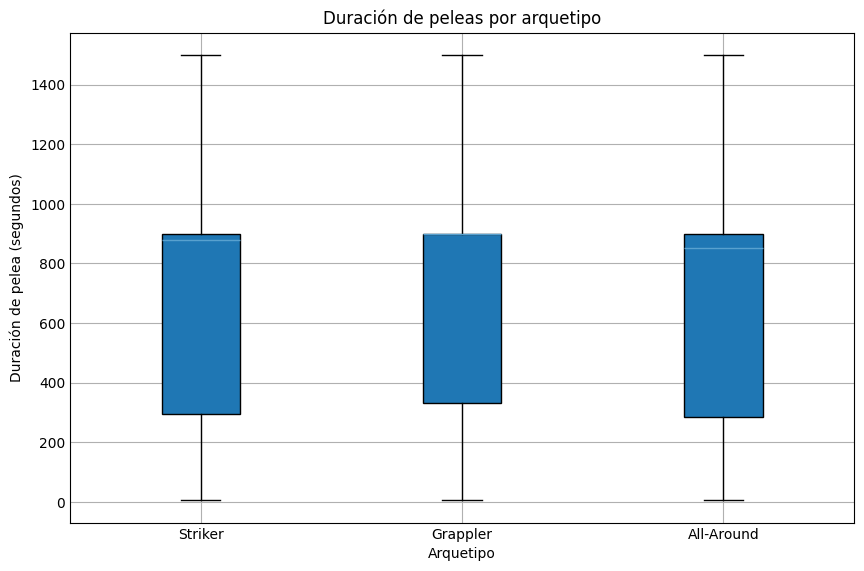

In [252]:
plt.style.use('_mpl-gallery')

arquetipos = ['Striker', 'Grappler', 'All-Around']
data = [
    df_arq_time[df_arq_time['arquetipo_winner'] == arq]['total_fight_time_secs'].dropna()
    for arq in arquetipos
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=arquetipos, patch_artist=True)
ax.set_xlabel('Arquetipo')
ax.set_ylabel('Duración de pelea (segundos)')
ax.set_title('Duración de peleas por arquetipo')
plt.show()

/tmp/ipykernel_2714/1798596815.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=arquetipos, patch_artist=True)


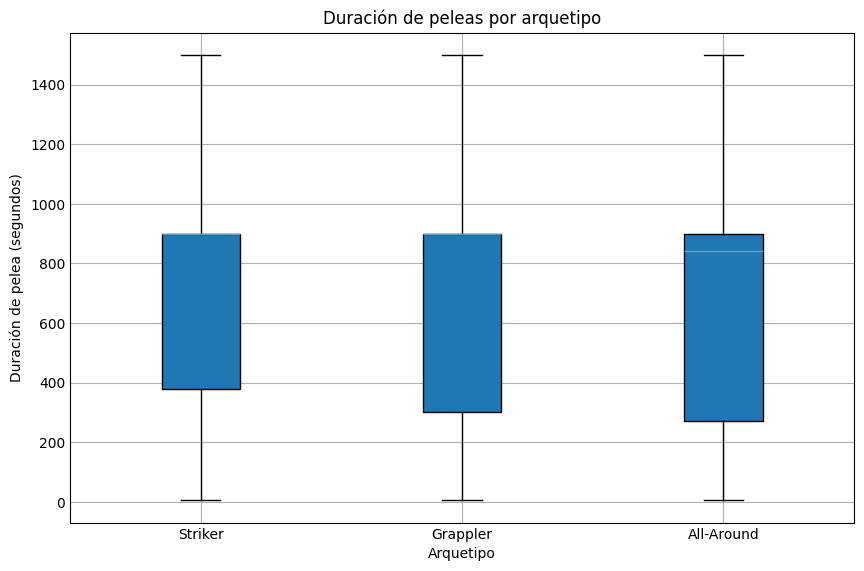

In [253]:
plt.style.use('_mpl-gallery')

arquetipos = ['Striker', 'Grappler', 'All-Around']
data = [
    df_arq_time[df_arq_time['arquetipo_losser'] == arq]['total_fight_time_secs'].dropna()
    for arq in arquetipos
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=arquetipos, patch_artist=True)
ax.set_xlabel('Arquetipo')
ax.set_ylabel('Duración de pelea (segundos)')
ax.set_title('Duración de peleas por arquetipo')
plt.show()

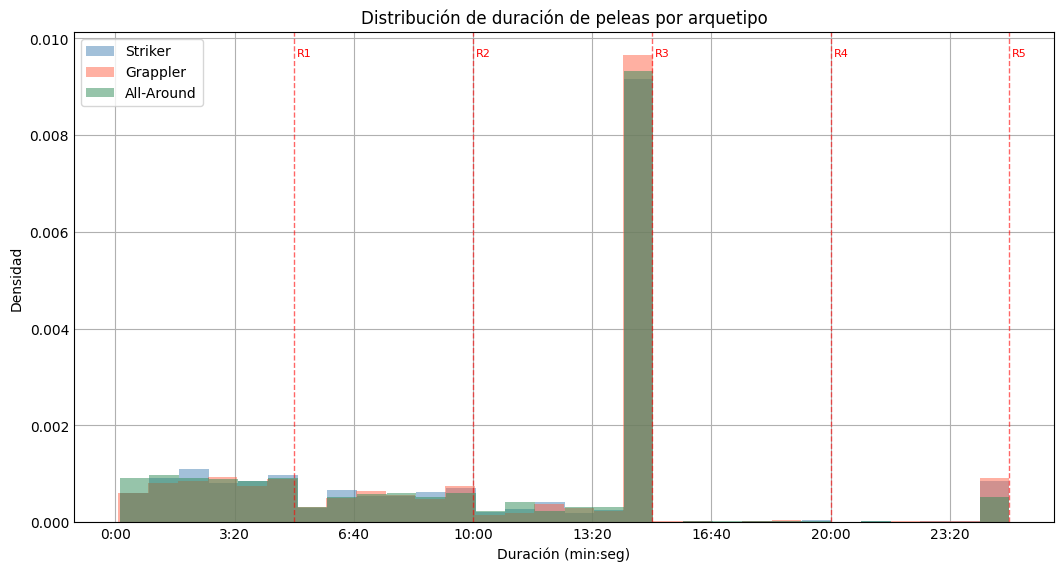

In [247]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = {'Striker': 'steelblue', 'Grappler': 'tomato', 'All-Around': 'seagreen'}

for arq, color in colores.items():
    subset = df_arq_time[df_arq_time['arquetipo_winner'] == arq]['total_fight_time_secs'].dropna()
    ax.hist(subset, bins=30, alpha=0.5, label=arq, color=color, density=True)

# Líneas de round
for round_num in range(1, 6):
    ax.axvline(x=round_num * 300, color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(round_num * 300 + 5, ax.get_ylim()[1] * 0.95, f'R{round_num}', 
            color='red', fontsize=8)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x//60)}:{int(x%60):02d}'))
ax.set_xlabel('Duración (min:seg)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de duración de peleas por arquetipo')
ax.legend()
plt.show()

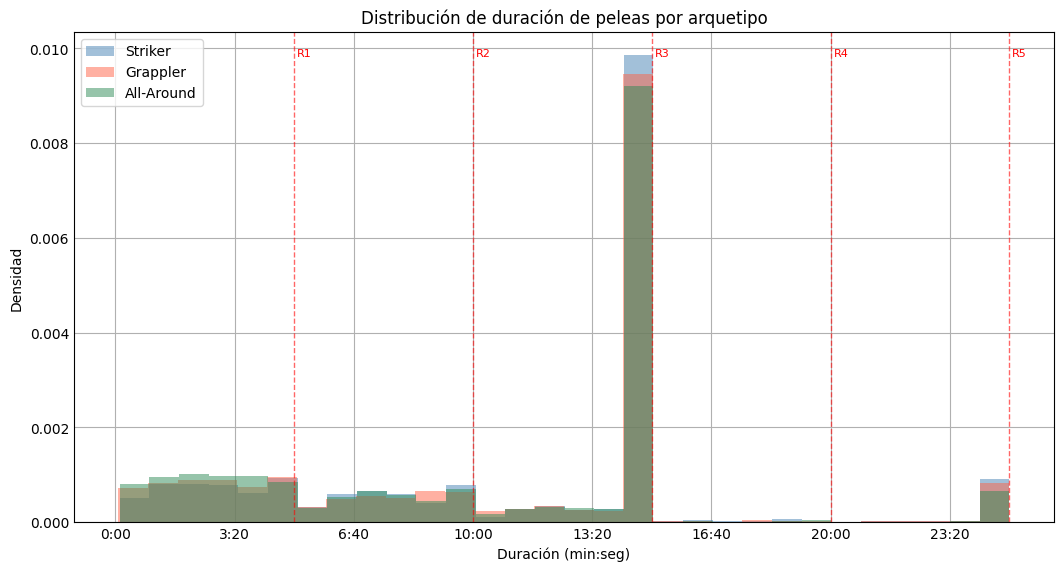

In [249]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = {'Striker': 'steelblue', 'Grappler': 'tomato', 'All-Around': 'seagreen'}

for arq, color in colores.items():
    subset = df_arq_time[df_arq_time['arquetipo_losser'] == arq]['total_fight_time_secs'].dropna()
    ax.hist(subset, bins=30, alpha=0.5, label=arq, color=color, density=True)

# Líneas de round
for round_num in range(1, 6):
    ax.axvline(x=round_num * 300, color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(round_num * 300 + 5, ax.get_ylim()[1] * 0.95, f'R{round_num}', 
            color='red', fontsize=8)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x//60)}:{int(x%60):02d}'))
ax.set_xlabel('Duración (min:seg)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de duración de peleas por arquetipo')
ax.legend()
plt.show()

In [256]:
df_record_arq = df_peleador_record.merge(
    df_peleador_acciones[['fighter', 'arquetipo_base']],
    on='fighter', how='left'
).dropna(subset=['arquetipo_base'])

# 2. Calcular win_rate por arquetipo
df_record_arq['win_rate'] = df_record_arq['wins'] / df_record_arq['total_fights']
df_record_arq['loss_rate'] = df_record_arq['losses'] / df_record_arq['total_fights']
df_record_arq['draw_rate'] = df_record_arq['draws'] / df_record_arq['total_fights']

# 3. Agrupar por arquetipo
df_arq_stats = df_record_arq.groupby('arquetipo_base').agg(
    win_rate=('win_rate', 'mean'),
    loss_rate=('loss_rate', 'mean'),
    draw_rate=('draw_rate', 'mean'),
    n_fighters=('fighter', 'count')
).reset_index()

print(df_arq_stats)  # Validar antes de graficar

  arquetipo_base  win_rate  loss_rate  draw_rate  n_fighters
0     All-Around  0.323520   0.675698   0.000782         939
1       Grappler  0.471345   0.527852   0.000803         909
2        Striker  0.372998   0.626881   0.000121         393


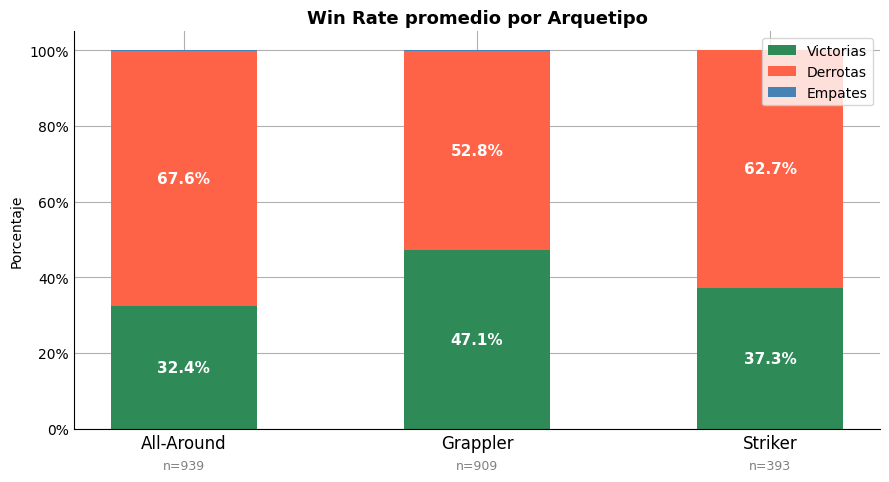

In [262]:
fig, ax = plt.subplots(figsize=(9, 5))

arquetipos = df_arq_stats['arquetipo_base']
x = np.arange(len(arquetipos))
width = 0.5

colores = {
    'win_rate':  'seagreen',
    'loss_rate': 'tomato',
    'draw_rate': 'steelblue'
}

bars_w = ax.bar(x, df_arq_stats['win_rate'],  width, label='Victorias', color=colores['win_rate'])
bars_l = ax.bar(x, df_arq_stats['loss_rate'], width, label='Derrotas',  color=colores['loss_rate'],
                bottom=df_arq_stats['win_rate'])
bars_d = ax.bar(x, df_arq_stats['draw_rate'], width, label='Empates',   color=colores['draw_rate'],
                bottom=df_arq_stats['win_rate'] + df_arq_stats['loss_rate'])

# Etiquetas de % dentro de cada barra
for i, row in df_arq_stats.iterrows():
    # Win
    ax.text(i, row['win_rate'] / 2,
            f"{row['win_rate']:.1%}", ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    # Loss
    ax.text(i, row['win_rate'] + row['loss_rate'] / 2,
            f"{row['loss_rate']:.1%}", ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

# N de peleadores bajo cada barra
for i, row in df_arq_stats.iterrows():
    ax.text(i, -0.08, f"n={int(row['n_fighters'])}",
            ha='center', va='top', fontsize=9, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(arquetipos, fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1.05)
ax.set_ylabel('Porcentaje')
ax.set_title('Win Rate promedio por Arquetipo', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()